Eğitim Başlatılıyor (cuda:0)...

--- Epoch 1/5 ---
Batch [200/1121] | Anlık Loss: 0.0230
Batch [400/1121] | Anlık Loss: 0.0962
Batch [600/1121] | Anlık Loss: 0.0241
Batch [800/1121] | Anlık Loss: 0.0752
Batch [1000/1121] | Anlık Loss: 0.0290
Batch [1121/1121] | Anlık Loss: 0.2901
Epoch 1 -> Train Loss: 0.0955 | Train Acc: 0.9641 | Val Acc: 0.9886
>> En iyi model kaydedildi: Acc = 0.9886

--- Epoch 2/5 ---
Batch [200/1121] | Anlık Loss: 0.0043
Batch [400/1121] | Anlık Loss: 0.0112
Batch [600/1121] | Anlık Loss: 0.0330
Batch [800/1121] | Anlık Loss: 0.0257
Batch [1000/1121] | Anlık Loss: 0.0711
Batch [1121/1121] | Anlık Loss: 0.0129
Epoch 2 -> Train Loss: 0.0434 | Train Acc: 0.9855 | Val Acc: 0.9872

--- Epoch 3/5 ---
Batch [200/1121] | Anlık Loss: 0.0006
Batch [400/1121] | Anlık Loss: 0.0228
Batch [600/1121] | Anlık Loss: 0.0093
Batch [800/1121] | Anlık Loss: 0.0351
Batch [1000/1121] | Anlık Loss: 0.0200
Batch [1121/1121] | Anlık Loss: 0.0035
Epoch 3 -> Train Loss: 0.0326 | Train Acc: 0

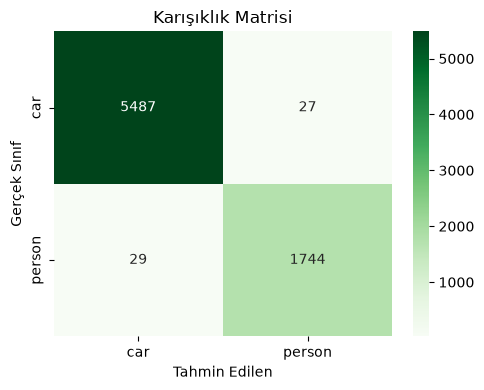

In [1]:
import sys
sys.path.append('..')

import torch
import torch.nn as nn
import torch.optim as optim
from src.dataset import get_dataloaders
from src.models import build_mobilenetv3
from src.engine import train_model, evaluate_and_plot

# 1. Cihaz ve Veri
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
train_loader, val_loader, class_weights, class_names = get_dataloaders(data_dir="../dataset/raw", batch_size=32)

# 2. Model, Kayıp Fonksiyonu ve Optimizer
model = build_mobilenetv3(num_classes=2, pretrained=True).to(device)
criterion = nn.CrossEntropyLoss(weight=class_weights.to(device))
optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-2)

# 3. Eğitim
SAVE_PATH = "../models/best_mobilenetv3.pth"
train_model(model, train_loader, val_loader, criterion, optimizer, device, save_path=SAVE_PATH, epochs=5)

# 4. Değerlendirme
evaluate_and_plot(model, val_loader, class_names, device, weight_path=SAVE_PATH, cmap='Greens')